# Stacking and voting

### Combining different model families, and measuring whether it paid

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Hard against soft voting, why an ensemble only pays when its members fail on different rows, how a meta-model learns to weight base models, why its training features must be out-of-fold, and what all of it costs |
| **You should already know** | [Bagging](../01-bagging/), [cross-validation](../../01-foundations/04-cross-validation/), [logistic regression](../../03-classification/01-logistic-regression/) |
| **Datasets** | UCI Dry Bean, California Housing |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [05-01 k-Means](../../05-unsupervised/01-k-means/) |

---

## 1. The idea

[Bagging](../01-bagging/) and [gradient boosting](../05-gradient-boosting/) build
an ensemble out of many copies of one model. This notebook does the opposite. It
takes six models that were never designed to work together (a linear one, a
distance one, two tree ones, a probabilistic one) and asks them to agree on a
bean.

The reason that can work is the same reason bagging works, stated more generally.
**An ensemble beats its best member only when the members are wrong on different
rows.** If they all fail on the same hard beans, the majority fails there too and
averaging changes nothing. Different families fail differently, and that is the
entire argument for mixing them.

There are two ways to combine. **Voting** applies a fixed rule: take the majority
label, or average the predicted probabilities. **Stacking** trains a second model,
the *meta-model*, to learn the rule from data: which member to believe, and for
which class.

Stacking carries one trap, and it is why this notebook is longer than it looks
like it should be. The meta-model trains on features that are base-model
predictions. If those predictions come from rows the base models were fitted on,
they are far better than anything the meta-model will meet at test time, and it
learns to trust whichever member memorises hardest. The fix is to generate them
out-of-fold. In section 4 I do it wrong on purpose so the damage is visible.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. Hard and soft voting

**Hard voting** counts labels. Each member names one class, and the class named
most often wins. **Soft voting** averages the predicted probability vectors and
takes the argmax of the average.

The difference is what happens to a member that is unsure. Under hard voting, a
member that is barely leaning one way shouts its winner exactly as loudly as a
member that is certain. Under soft voting the hesitant member barely moves the
average, and one confident member can overrule two doubtful ones. Confidence is
information, and hard voting throws it away.

Six members, one from each family I would actually reach for on tabular data.
Everything that needs scaling gets it inside a pipeline, so the scaler is refitted
on each training fold rather than on the whole file.

In [2]:
import time

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

X, y = datasets.dry_bean()
X_all, y_all = X.to_numpy(), y.to_numpy()

# Stacking refits every member once per fold, so I work on a stratified slice of
# the file. The ordering of the members is the same on all 13,611 rows; only the
# wall clock changes.
X_work, _, y_work, _ = train_test_split(
    X_all, y_all, train_size=9000, stratify=y_all, random_state=SEED)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_work, y_work, test_size=0.3, stratify=y_work, random_state=SEED)

# No member is given extra worker processes, so the fit times in section 5 compare.
members = {
    "logistic": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "k-NN (15)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
    "decision tree": DecisionTreeClassifier(random_state=SEED),
    "random forest": RandomForestClassifier(n_estimators=100, random_state=SEED),
    "grad boosting": HistGradientBoostingClassifier(max_iter=60, learning_rate=0.15,
                                                    random_state=SEED),
    "naive Bayes": GaussianNB(),
}
names = list(members)

fitted, fit_time, proba, pred = {}, {}, {}, {}
for name, model in members.items():
    start = time.perf_counter()
    fitted[name] = model.fit(X_tr, y_tr)
    fit_time[name] = time.perf_counter() - start
    proba[name] = fitted[name].predict_proba(X_te)
    pred[name] = fitted[name].predict(X_te)

CLASSES = fitted["logistic"].classes_          # sorted, and shared by every member
accuracy = {n: float((pred[n] == y_te).mean()) for n in names}
best_member = max(accuracy, key=accuracy.get)

print(f"train {X_tr.shape}   test {X_te.shape}   classes {len(CLASSES)}\n")
for n in names:
    print(f"{n:>14}: test accuracy {accuracy[n]:.4f}   fit {fit_time[n]:6.2f}s")
print(f"\nbest single member: {best_member}")

train (6300, 16)   test (2700, 16)   classes 7

      logistic: test accuracy 0.9170   fit   0.12s
     k-NN (15): test accuracy 0.9148   fit   0.01s
 decision tree: test accuracy 0.8844   fit   0.16s
 random forest: test accuracy 0.9100   fit   1.91s
 grad boosting: test accuracy 0.9185   fit   1.47s
   naive Bayes: test accuracy 0.7493   fit   0.01s

best single member: grad boosting


In [3]:
index_of = {c: i for i, c in enumerate(CLASSES)}

# Hard vote: count labels. On ties argmax takes the lowest class index, which is
# what scikit-learn does too, and with an even number of members ties happen.
counts = np.zeros((len(y_te), len(CLASSES)))
for n in names:
    counts[np.arange(len(y_te)), [index_of[v] for v in pred[n]]] += 1
hard_pred = CLASSES[counts.argmax(axis=1)]
ties = int((counts.max(axis=1) == np.sort(counts, axis=1)[:, -2]).sum())

# Soft vote: average the probability vectors, then take the argmax.
mean_proba = np.mean([proba[n] for n in names], axis=0)
soft_pred = CLASSES[mean_proba.argmax(axis=1)]

hard_acc = float((hard_pred == y_te).mean())
soft_acc = float((soft_pred == y_te).mean())

print(f"best single member ({best_member}): {accuracy[best_member]:.4f}")
print(f"hard vote, majority label      : {hard_acc:.4f}   ({hard_acc - accuracy[best_member]:+.4f})")
print(f"soft vote, mean probability    : {soft_acc:.4f}   ({soft_acc - accuracy[best_member]:+.4f})")
print(f"\nsoft minus hard               : {soft_acc - hard_acc:+.4f}")
print(f"rows where the two disagree    : {int((hard_pred != soft_pred).sum())} of {len(y_te)}")
print(f"rows where the hard vote tied  : {ties}")

best single member (grad boosting): 0.9185
hard vote, majority label      : 0.9185   (+0.0000)
soft vote, mean probability    : 0.9181   (-0.0004)

soft minus hard               : -0.0004
rows where the two disagree    : 58 of 2700
rows where the hard vote tied  : 53


In [4]:
# One row where confidence decided it, printed member by member.
rescued = np.flatnonzero((soft_pred == y_te) & (hard_pred != y_te))

if rescued.size:
    row = int(rescued[0])
    truth = y_te[row]
    table = pd.DataFrame({
        "says": [pred[n][row] for n in names],
        "how sure": [float(proba[n][row].max()) for n in names],
        "P(truth)": [float(proba[n][row][index_of[truth]]) for n in names],
    }, index=names)
    print(f"test row {row}, true class {truth}")
    print(f"hard vote said {hard_pred[row]}, soft vote said {soft_pred[row]}\n")
    print(table.round(3).to_string())
else:
    print("in this split the soft vote never rescued a row the hard vote lost")

print("\nmean confidence in its own winner, across the test set:")
for n in names:
    print(f"  {n:>14}: {proba[n].max(axis=1).mean():.3f}")

test row 69, true class SIRA
hard vote said HOROZ, soft vote said SIRA

                says  how sure  P(truth)
logistic       HOROZ     0.508     0.476
k-NN (15)       SIRA     0.667     0.667
decision tree  HOROZ     1.000     0.000
random forest  HOROZ     0.520     0.460
grad boosting  HOROZ     0.607     0.393
naive Bayes     SIRA     0.998     0.998

mean confidence in its own winner, across the test set:
        logistic: 0.906
       k-NN (15): 0.912
   decision tree: 1.000
   random forest: 0.910
   grad boosting: 0.970
     naive Bayes: 0.902


The members that lose the vote are usually the ones that were unsure, and soft
voting is the only version that can tell. That is why I reach for it by default.

The mean-confidence list is the caveat. Naive Bayes multiplies independent
likelihoods it does not really have, so it tends to report near-certainty whether
or not it deserves to. A loud member drags the average toward itself regardless of
skill, and soft voting has no defence against that: this is the situation
probability calibration exists for. Stacking does have a defence, because the
meta-model can simply learn to discount that member. Section 4 shows it doing so.

## 3. Diversity is the whole requirement

I want to measure the claim from section 1 rather than repeat it. For each member
I take its error indicator on the test set: one per row, true when the member got
that row wrong. The correlation between two members' error indicators says how far
they share their failures. One means identical mistakes and nothing to gain.
Zero means independent mistakes. Negative means one tends to be right exactly
where the other is wrong, which is the ideal an ensemble is chasing.

The right panel puts the claim on trial. I take every three-member subset, average
the pairwise error correlations inside it, and plot that against what soft voting
bought that subset over its own best member.

mean pairwise error correlation across the six members: 0.540
most alike : logistic and k-NN (15)  (0.740)
least alike: grad boosting and naive Bayes  (0.287)

trios: best gain +0.0037, worst gain -0.0159
correlation between trio similarity and trio gain: r = 0.36


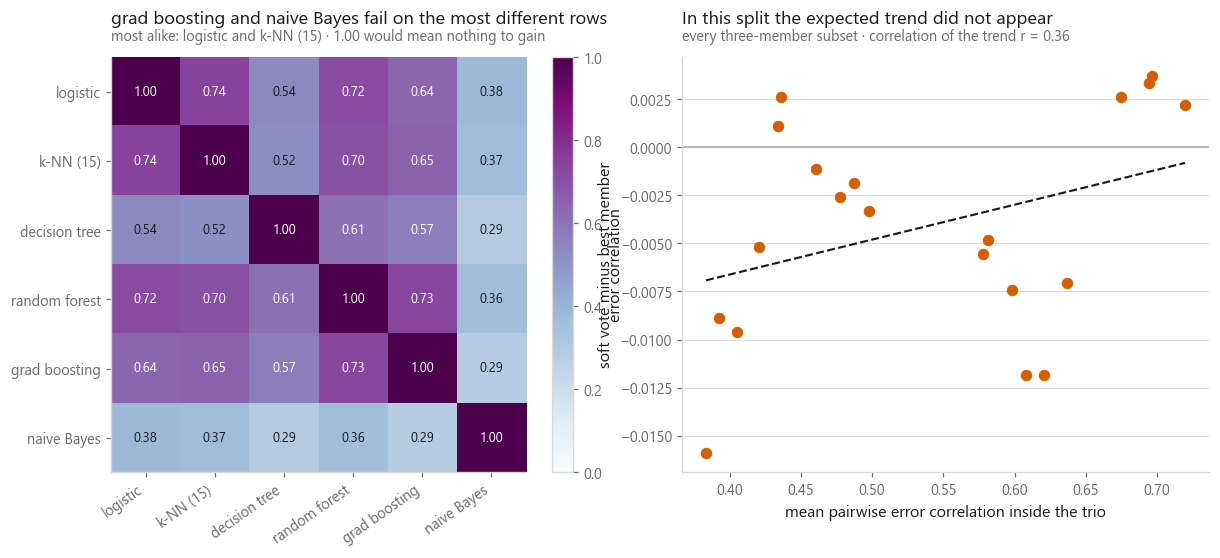

In [5]:
from itertools import combinations

errors = np.array([(pred[n] != y_te).astype(float) for n in names])
corr = np.corrcoef(errors)
off_diagonal = ~np.eye(len(names), dtype=bool)

rows = []
for trio in combinations(range(len(names)), 3):
    inner = float(np.mean([corr[i, j] for i, j in combinations(trio, 2)]))
    trio_proba = np.mean([proba[names[k]] for k in trio], axis=0)
    trio_acc = float((CLASSES[trio_proba.argmax(1)] == y_te).mean())
    rows.append((inner, trio_acc - max(accuracy[names[k]] for k in trio)))
trios = pd.DataFrame(rows, columns=["correlation", "gain"])

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.9))

im = axes[0].imshow(corr, cmap="BuPu", vmin=0, vmax=1)
axes[0].set_xticks(range(len(names)), names, rotation=35, ha="right")
axes[0].set_yticks(range(len(names)), names)
for i in range(len(names)):
    for j in range(len(names)):
        axes[0].text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=8.5,
                     color="white" if corr[i, j] > 0.55 else style.INK)
axes[0].grid(visible=False)
fig.colorbar(im, ax=axes[0], fraction=0.046, label="error correlation")

masked = np.where(off_diagonal, corr, np.nan)
hi = np.unravel_index(np.nanargmax(masked), corr.shape)
lo = np.unravel_index(np.nanargmin(masked), corr.shape)
style.title(axes[0], f"{names[lo[0]]} and {names[lo[1]]} fail on the most different rows",
            f"most alike: {names[hi[0]]} and {names[hi[1]]} · 1.00 would mean nothing to gain")

r = float(np.corrcoef(trios["correlation"].to_numpy(), trios["gain"].to_numpy())[0, 1])
slope, intercept = np.polyfit(trios["correlation"].to_numpy(), trios["gain"].to_numpy(), 1)
grid = np.linspace(trios["correlation"].min(), trios["correlation"].max(), 50)
axes[1].axhline(0, color=style.NEUTRAL, lw=1.1)
axes[1].plot(grid, slope * grid + intercept, color=style.INK, ls="--", lw=1.4)
axes[1].scatter(trios["correlation"], trios["gain"], s=46, color=style.HIGHLIGHT,
                marker=style.MARKERS[0], zorder=3)
axes[1].set_xlabel("mean pairwise error correlation inside the trio")
axes[1].set_ylabel("soft vote minus best member")
verdict = ("The more alike the members, the less voting buys" if r < 0
           else "In this split the expected trend did not appear")
style.title(axes[1], verdict, f"every three-member subset · correlation of the trend r = {r:.2f}")

style.save(fig, FIG / "fig-01-error-correlation.png")

print(f"mean pairwise error correlation across the six members: {corr[off_diagonal].mean():.3f}")
print(f"most alike : {names[hi[0]]} and {names[hi[1]]}  ({corr[hi]:.3f})")
print(f"least alike: {names[lo[0]]} and {names[lo[1]]}  ({corr[lo]:.3f})")
print(f"\ntrios: best gain {trios['gain'].max():+.4f}, worst gain {trios['gain'].min():+.4f}")
print(f"correlation between trio similarity and trio gain: r = {r:.2f}")

In [6]:
# The control: five members from one family, differing only in a hyperparameter.
copies = {f"k-NN ({k})": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
          for k in [9, 13, 17, 21, 25]}
copy_proba, copy_pred = {}, {}
for n, model in copies.items():
    model.fit(X_tr, y_tr)
    copy_proba[n] = model.predict_proba(X_te)
    copy_pred[n] = model.predict(X_te)

copy_corr = np.corrcoef(np.array([(copy_pred[n] != y_te).astype(float) for n in copies]))
copy_off = ~np.eye(len(copies), dtype=bool)
copy_vote = CLASSES[np.mean([copy_proba[n] for n in copies], axis=0).argmax(1)]
copy_vote_acc = float((copy_vote == y_te).mean())
copy_best = max(float((copy_pred[n] == y_te).mean()) for n in copies)

print(f"five k-NN variants    : mean error correlation {copy_corr[copy_off].mean():.3f}")
print(f"six different families: mean error correlation {corr[off_diagonal].mean():.3f}\n")
print(f"soft vote of the k-NN variants: {copy_vote_acc:.4f}   best variant {copy_best:.4f}   "
      f"gain {copy_vote_acc - copy_best:+.4f}")
print(f"soft vote of the six families : {soft_acc:.4f}   best member  {accuracy[best_member]:.4f}   "
      f"gain {soft_acc - accuracy[best_member]:+.4f}")

five k-NN variants    : mean error correlation 0.888
six different families: mean error correlation 0.540

soft vote of the k-NN variants: 0.9144   best variant 0.9137   gain +0.0007
soft vote of the six families : 0.9181   best member  0.9185   gain -0.0004


Five k-nearest-neighbour models with different $k$ are five views of the same
geometry. They agree on which beans are confusing, their error correlations sit
near one, and voting between them recovers almost nothing. Averaging cannot cancel
an error that every member makes.

This is the same wall [bagging](../01-bagging/) hits when its accuracy curve
flattens: bootstrap samples overlap, so bootstrap models correlate. Mixing
families is how you get past it, and the correlation matrix is how you check that
you did before spending an afternoon on the ensemble.

## 4. Stacking, and the out-of-fold rule

Voting fixes the combining rule in advance. Stacking learns it. The meta-model
receives every member's probability vector as its input features and predicts the
class, so it can learn that one member is reliable on Bombay beans and useless on
Sira, or that another member's confidence should be scaled down everywhere.

Here is the trap. To train the meta-model I need base-model predictions on
labelled rows. The obvious move is to fit the base models on the training set and
predict the training set, and that ruins everything. An unpruned decision tree
scores perfectly on rows it was grown from. The meta-model reads that column,
concludes the tree is an oracle, and gives it all the weight. At test time the
tree behaves like a tree and the meta-model is left holding a rule it learned from
a fantasy.

The fix is **out-of-fold predictions**. Split the training set into folds, fit each
base model on all folds but one, predict the held-out fold, and repeat until every
training row has a prediction made by a model that never saw it. Those columns look
like what the meta-model will meet in production, because they were produced the
same way.

The gap below is the whole story.

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict

folds = StratifiedKFold(5, shuffle=True, random_state=SEED)

start = time.perf_counter()
oof, in_sample = {}, {}
for n, model in members.items():
    # cross_val_predict clones the estimator, so the fits above are not reused here
    oof[n] = cross_val_predict(model, X_tr, y_tr, cv=folds, method="predict_proba")
    in_sample[n] = fitted[n].predict_proba(X_tr)
oof_time = time.perf_counter() - start

print(f"{'member':>14}  {'in-sample':>10}  {'out-of-fold':>12}  {'gap':>8}")
for n in names:
    a = float((CLASSES[in_sample[n].argmax(1)] == y_tr).mean())
    b = float((CLASSES[oof[n].argmax(1)] == y_tr).mean())
    print(f"{n:>14}  {a:>10.4f}  {b:>12.4f}  {a - b:>+8.4f}")
print(f"\nbuilding the out-of-fold columns took {oof_time:.1f}s")

        member   in-sample   out-of-fold       gap
      logistic      0.9251        0.9229   +0.0022
     k-NN (15)      0.9322        0.9216   +0.0106
 decision tree      1.0000        0.8921   +0.1079
 random forest      1.0000        0.9200   +0.0800
 grad boosting      1.0000        0.9192   +0.0808
   naive Bayes      0.7724        0.7694   +0.0030

building the out-of-fold columns took 16.9s


In [8]:
meta_honest_X = np.hstack([oof[n] for n in names])          # produced by models that never saw the row
meta_leaky_X = np.hstack([in_sample[n] for n in names])     # produced by models that did
meta_test_X = np.hstack([proba[n] for n in names])

honest = LogisticRegression(max_iter=3000).fit(meta_honest_X, y_tr)
leaky = LogisticRegression(max_iter=3000).fit(meta_leaky_X, y_tr)

honest_apparent = float(honest.score(meta_honest_X, y_tr))
leaky_apparent = float(leaky.score(meta_leaky_X, y_tr))
honest_test = float(honest.score(meta_test_X, y_te))
leaky_test = float(leaky.score(meta_test_X, y_te))

print(f"{'meta-model trained on':>24}  {'what it claims':>15}  {'what it gets':>13}")
print(f"{'out-of-fold columns':>24}  {honest_apparent:>15.4f}  {honest_test:>13.4f}")
print(f"{'in-sample columns':>24}  {leaky_apparent:>15.4f}  {leaky_test:>13.4f}")
print(f"\ninflation the leak invents : {leaky_apparent - honest_test:+.4f}")
print(f"what the leak actually costs: {leaky_test - honest_test:+.4f}")
print(f"soft vote, for reference    : {soft_acc:.4f}")
print(f"best single member          : {accuracy[best_member]:.4f}")

   meta-model trained on   what it claims   what it gets
     out-of-fold columns           0.9310         0.9207
       in-sample columns           1.0000         0.9130

inflation the leak invents : +0.0793
what the leak actually costs: -0.0078
soft vote, for reference    : 0.9181
best single member          : 0.9185


Two separate harms, and they are worth naming separately.

The first is the reported score. The leaky meta-model claims a training accuracy
that no held-out data will ever confirm, so anyone reading that number to decide
whether to ship the ensemble is reading fiction.

The second is the model itself. Trained on columns where one member looks
infallible, it learns a weighting that is wrong for real inputs, and it carries
that wrong weighting into test time. This is why the mistake is worse than a
reporting error: you do not merely misjudge the model, you build a worse one.

The weights show it directly.

        member   honest mean   leaky mean   trusted most on
      logistic         +1.75        +0.81   HOROZ (+2.42)
     k-NN (15)         +1.66        +0.88   HOROZ (+2.60)
 decision tree         +0.36        +1.88   BOMBAY (+1.08)
 random forest         +1.19        +1.48   DERMASON (+1.70)
 grad boosting         +0.44        +1.86   BOMBAY (+1.11)
   naive Bayes         +0.58        +0.52   BOMBAY (+1.33)

honest: widest spread of trust across members 1.39
leaky : widest spread of trust across members 1.37


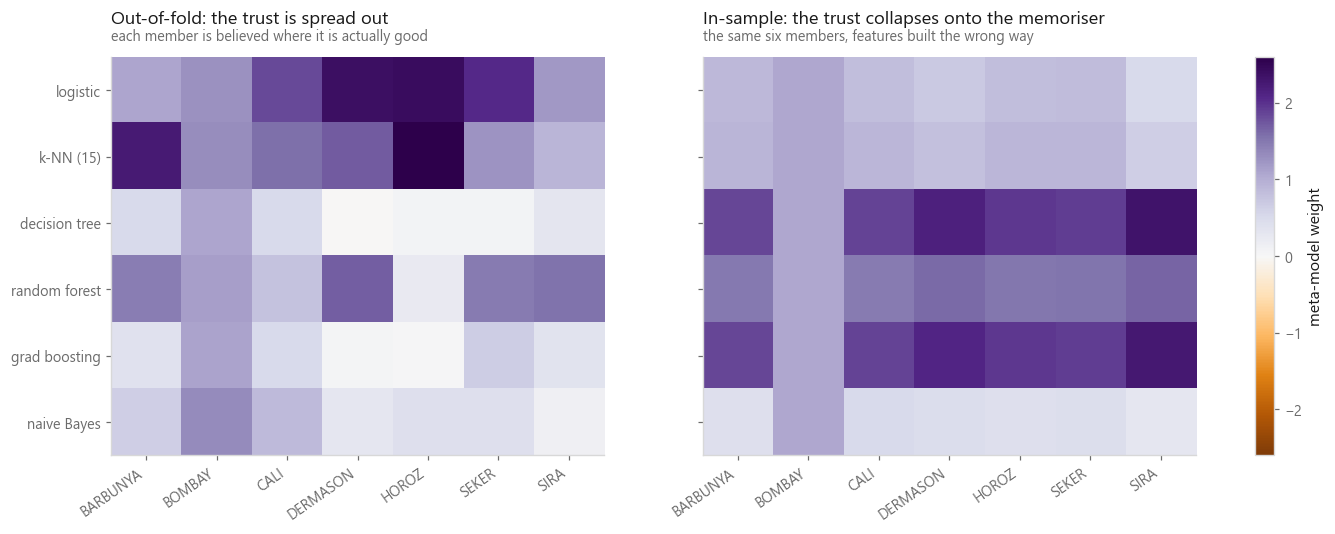

In [9]:
K = len(CLASSES)
assert honest.coef_.shape == (K, len(names) * K)   # one probability block per member


def trust(meta):
    """How much the meta-model leans on member m when scoring class c.

    Column m*K + c is member m's probability for class c, and row c is the
    meta-model's score for class c, so coef_[c, m*K + c] is the direct link.
    """
    return np.array([[meta.coef_[c, m * K + c] for c in range(K)] for m in range(len(names))])


W_honest, W_leaky = trust(honest), trust(leaky)
limit = float(max(abs(W_honest).max(), abs(W_leaky).max()))

fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.7), sharey=True)
panels = [
    (axes[0], W_honest, "Out-of-fold: the trust is spread out",
     "each member is believed where it is actually good"),
    (axes[1], W_leaky, "In-sample: the trust collapses onto the memoriser",
     "the same six members, features built the wrong way"),
]
for ax, W, head, sub in panels:
    im = ax.imshow(W, cmap="PuOr", vmin=-limit, vmax=limit, aspect="auto")
    ax.set_xticks(range(K), CLASSES, rotation=35, ha="right")
    ax.set_yticks(range(len(names)), names)
    ax.grid(visible=False)
    style.title(ax, head, sub)
fig.colorbar(im, ax=axes, fraction=0.028, label="meta-model weight")
style.save(fig, FIG / "fig-02-meta-weights.png")

print(f"{'member':>14}  {'honest mean':>12}  {'leaky mean':>11}   trusted most on")
for i, n in enumerate(names):
    top = int(W_honest[i].argmax())
    print(f"{n:>14}  {W_honest[i].mean():>+12.2f}  {W_leaky[i].mean():>+11.2f}   "
          f"{CLASSES[top]} ({W_honest[i, top]:+.2f})")
print(f"\nhonest: widest spread of trust across members "
      f"{W_honest.mean(axis=1).max() - W_honest.mean(axis=1).min():.2f}")
print(f"leaky : widest spread of trust across members "
      f"{W_leaky.mean(axis=1).max() - W_leaky.mean(axis=1).min():.2f}")

Read the honest panel by row. A row that is orange in one column and pale in
another is a member the meta-model believes for one bean variety and ignores for
the rest, which is exactly the behaviour voting cannot express: a vote gives every
member the same say on every class, forever.

Negative weights are worth pausing on too. A meta-model is allowed to *subtract* a
member, to treat its enthusiasm for a class as evidence against that class. No
voting rule can do that.

### The library version

`StackingClassifier` does what I just did by hand. The two arguments that matter
are `cv`, which is the out-of-fold rule made mandatory, and `stack_method`, which
decides whether the meta-model gets probabilities or bare labels. Probabilities,
for the same reason soft voting beat hard voting.

In [10]:
from sklearn.ensemble import StackingClassifier

start = time.perf_counter()
stack = StackingClassifier(
    estimators=[(n, members[n]) for n in names],
    final_estimator=LogisticRegression(max_iter=3000),
    stack_method="predict_proba",   # confidences, not labels
    cv=folds,                       # the out-of-fold rule, enforced for you
).fit(X_tr, y_tr)
stack_time = time.perf_counter() - start
stack_acc = float(stack.score(X_te, y_te))
stack_pred = stack.predict(X_te)

print(f"StackingClassifier : {stack_acc:.4f} in {stack_time:.1f}s")
print(f"my version by hand : {honest_test:.4f}")
print(f"difference         : {abs(stack_acc - honest_test):.4f}  (fold assignment aside, the same method)")

StackingClassifier : 0.9207 in 21.5s
my version by hand : 0.9207
difference         : 0.0000  (fold assignment aside, the same method)


      stacking: 0.9207
     hard vote: 0.9185
 grad boosting: 0.9185
     soft vote: 0.9181
      logistic: 0.9170
     k-NN (15): 0.9148
 random forest: 0.9100
 decision tree: 0.8844
   naive Bayes: 0.7493


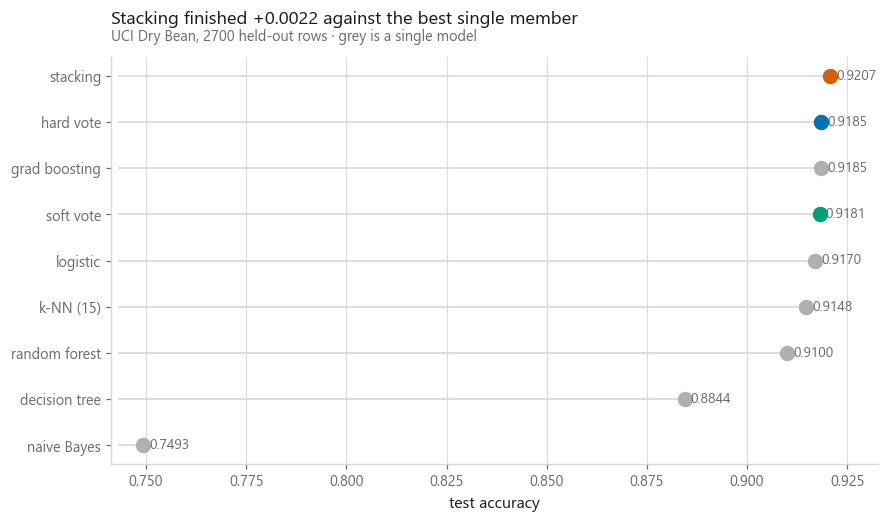

In [11]:
scores = {**accuracy, "hard vote": hard_acc, "soft vote": soft_acc, "stacking": stack_acc}
tone = {n: style.NEUTRAL for n in names}
tone.update({"hard vote": style.PALETTE[0], "soft vote": style.PALETTE[2],
             "stacking": style.HIGHLIGHT})
order = sorted(scores, key=scores.get)
floor = min(scores.values())

fig, ax = plt.subplots(figsize=(9.0, 4.8))
for rank, n in enumerate(order):
    ax.plot([floor - 0.006, scores[n]], [rank, rank], color=style.RULE, lw=1.1, zorder=0)
    ax.scatter(scores[n], rank, s=88, color=tone[n], marker=style.MARKERS[0], zorder=3)
    ax.text(scores[n] + 0.0015, rank, f"{scores[n]:.4f}", va="center", fontsize=9,
            color=style.MUTED)
ax.set_yticks(range(len(order)), order)
ax.set_xlim(floor - 0.008, max(scores.values()) + 0.012)
ax.set_xlabel("test accuracy")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
style.title(ax, f"Stacking finished {stack_acc - accuracy[best_member]:+.4f} against the best single member",
            f"UCI Dry Bean, {len(y_te)} held-out rows · grey is a single model")
style.save(fig, FIG / "fig-03-members-vs-ensembles.png")

for n in order[::-1]:
    print(f"{n:>14}: {scores[n]:.4f}")

### The same rule in regression

Nothing above was specific to classification. `StackingRegressor` takes the same
`cv` argument for the same reason, and the meta-model becomes a small linear
regression on the members' predictions, which makes its weights unusually easy to
read.

In [12]:
from sklearn.ensemble import HistGradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from sklearn.neighbors import KNeighborsRegressor

Xh, yh = datasets.california_housing()
rng = np.random.default_rng(SEED)
keep = rng.choice(len(yh), 6000, replace=False)     # a random slice, not the first rows,
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(      # because the file is ordered by district
    Xh.to_numpy()[keep], yh.to_numpy()[keep], test_size=0.3, random_state=SEED)

reg_members = [
    ("ridge", make_pipeline(StandardScaler(), RidgeCV())),
    ("k-NN", make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=12))),
    ("boosting", HistGradientBoostingRegressor(max_iter=120, random_state=SEED)),
]
for n, model in reg_members:
    model.fit(Xh_tr, yh_tr)
    print(f"{n:>14}: test R2 {model.score(Xh_te, yh_te):.4f}")

plain_average = np.mean([model.predict(Xh_te) for _, model in reg_members], axis=0)
print(f"{'plain average':>14}: test R2 {r2_score(yh_te, plain_average):.4f}")

reg_stack = StackingRegressor(estimators=reg_members, final_estimator=RidgeCV(),
                              cv=5).fit(Xh_tr, yh_tr)
print(f"{'stacking':>14}: test R2 {reg_stack.score(Xh_te, yh_te):.4f}")

weights = ", ".join(f"{n} {w:+.2f}" for (n, _), w in
                    zip(reg_members, reg_stack.final_estimator_.coef_))
print(f"\nmeta-model weights: {weights}")

         ridge: test R2 0.5845
          k-NN: test R2 0.6296


      boosting: test R2 0.7898
 plain average: test R2 0.7224


      stacking: test R2 0.7897

meta-model weights: ridge +0.02, k-NN +0.05, boosting +0.93


The plain average is the regression version of a vote: every member counted
equally whatever it is worth. The meta-model's weights are printed above, and if
any of them came out negative, that member is being used as a correction to the
others rather than as an opinion of its own.

## 5. What it actually costs

Every ensemble in this notebook was reported with its accuracy and none of them
with its bill, which is how ensembles get oversold. Stacking with $k$ folds and $M$
members costs $M(k + 1)$ base fits plus the meta-model, against one fit for a
single model. It also multiplies what you have to keep alive in production: every
member has to be trained, versioned, loaded and served, and the slowest one sets
your latency.

So the comparison worth making is not ensemble against single member. It is
ensemble against the best single member, in accuracy and in time, on held-out data.

best member  : 0.9185 in   1.5s
soft vote    : 0.9181 in   3.7s   (2.5x time, -0.0004 accuracy)
stacking     : 0.9207 in  21.5s   (14.7x time, +0.0022 accuracy)

stacking fixed 60 rows the best member got wrong, and broke 54 it had right
one standard error on a test accuracy at n = 2700 is 0.0053
the stacking gain is 0.4 standard errors


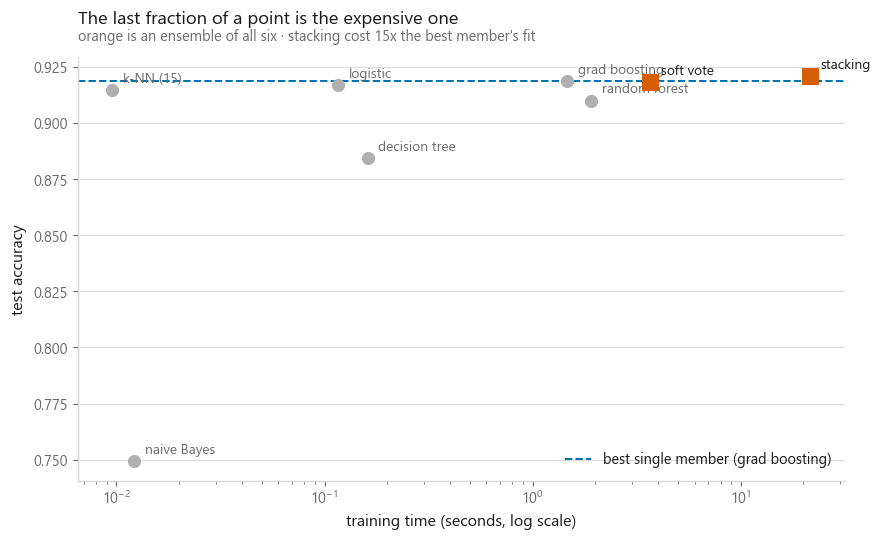

In [13]:
cost = {n: (fit_time[n], accuracy[n]) for n in names}
cost["soft vote"] = (sum(fit_time.values()), soft_acc)
cost["stacking"] = (stack_time, stack_acc)

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.axhline(accuracy[best_member], color=style.PALETTE[0], ls="--", lw=1.3,
           label=f"best single member ({best_member})")
for n, (seconds, score) in cost.items():
    grouped = n in ("soft vote", "stacking")
    ax.scatter(seconds, score, s=110 if grouped else 62,
               color=style.HIGHLIGHT if grouped else style.NEUTRAL,
               marker=style.MARKERS[1] if grouped else style.MARKERS[0], zorder=3)
    ax.annotate(n, (seconds, score), xytext=(7, 5), textcoords="offset points",
                fontsize=9, color=style.INK if grouped else style.MUTED)
ax.set_xscale("log")
ax.set_xlabel("training time (seconds, log scale)")
ax.set_ylabel("test accuracy")
ax.legend(loc="lower right")
style.title(ax, "The last fraction of a point is the expensive one",
            f"orange is an ensemble of all six · stacking cost "
            f"{stack_time / fit_time[best_member]:.0f}x the best member's fit")
style.save(fig, FIG / "fig-04-cost-and-gain.png")

se = float(np.sqrt(accuracy[best_member] * (1 - accuracy[best_member]) / len(y_te)))
best_pred = pred[best_member]
fixed = int(((best_pred != y_te) & (stack_pred == y_te)).sum())
broken = int(((best_pred == y_te) & (stack_pred != y_te)).sum())

print(f"best member  : {accuracy[best_member]:.4f} in {fit_time[best_member]:5.1f}s")
print(f"soft vote    : {soft_acc:.4f} in {sum(fit_time.values()):5.1f}s   "
      f"({sum(fit_time.values()) / fit_time[best_member]:.1f}x time, {soft_acc - accuracy[best_member]:+.4f} accuracy)")
print(f"stacking     : {stack_acc:.4f} in {stack_time:5.1f}s   "
      f"({stack_time / fit_time[best_member]:.1f}x time, {stack_acc - accuracy[best_member]:+.4f} accuracy)")
print(f"\nstacking fixed {fixed} rows the best member got wrong, and broke {broken} it had right")
print(f"one standard error on a test accuracy at n = {len(y_te)} is {se:.4f}")
print(f"the stacking gain is {abs(stack_acc - accuracy[best_member]) / se:.1f} standard errors")

Print the number of rows it fixed against the number it broke and the story gets
small very quickly. Compare the gain to one standard error on a test accuracy at
this sample size and it can get smaller still. Neither of those lines appears in a
leaderboard, and both of them decide whether the ensemble is real.

My own rule, after doing this on enough datasets: soft voting is nearly free once
the members exist and it rarely hurts, so it is a reasonable default. Stacking is
worth its cost when the members are genuinely different, when their error
correlation is low, and when a fraction of a point is worth six models in
production. On a well-tuned gradient boosting model with five look-alike friends,
it is a way to spend an afternoon.

## Cheat sheet

| | |
|---|---|
| **Hard voting** | Counts labels. Ignores confidence, ties on an even number of members, use it only when a member cannot give probabilities |
| **Soft voting** | Averages probability vectors. The default choice, but an overconfident member dominates it, so calibrate first |
| **Diversity** | Check the pairwise error correlation before building anything. Near one means there is nothing to win |
| **Stacking** | A meta-model learns the weights, per class, and may weight a member negatively |
| **The rule** | Meta-model features must be out-of-fold. `cv=` in `StackingClassifier` exists for this. Get it wrong and you inflate the reported score and damage the model |
| **Meta-model** | Keep it small. Logistic regression or ridge. A deep meta-model overfits six columns of correlated predictions |
| **Cost** | $M(k+1)$ fits, plus every member alive in production. Measure the gain against the best single member, not against the worst |
| **Next** | [k-Means](../../05-unsupervised/01-k-means/), where there are no labels to vote on |

## What to remember

1. Soft voting beats hard voting because it keeps the confidences. Hard voting
   lets a member that is barely leaning outvote a member that is certain.
2. An ensemble only pays when its members fail on different rows. Measure that
   with the correlation between their error indicators before you build it.
3. Copies of one family are not an ensemble. Five k-NN models with different $k$
   share their mistakes and vote themselves nowhere.
4. Stacking learns which member to trust, per class, and can give a member a
   negative weight. Voting can do neither.
5. The meta-model's training features must come from out-of-fold predictions. In
   sample they make a memorising member look infallible, which inflates the score
   you report and corrupts the weights you ship.
6. Stacking multiplies training time by roughly the number of members times the
   number of folds. Compare the gain to one standard error before believing it.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [05-01 k-Means](../../05-unsupervised/01-k-means/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#Ensemble` `#Stacking` `#VotingClassifier` `#ModelBlending`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#DataLeakage`